In [606]:
from transformer_architecture import Transformer

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [ ]:
df = pd.read_csv("data/cleaned_dataset.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,179.426579,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,179.426579,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,211.382074,60.0,652230.0,33.93911,67.709953


In [608]:
df[df["Entity"] == "Somalia"]

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
2520,Somalia,2000,1.892501,0.4,93.28,0.23,0.0,0.00,0.000000,340.10217,11.22,490.000000,350.168162,25.0,637657.0,5.152149,46.199616
2521,Somalia,2001,4.504616,0.4,93.26,0.25,0.0,0.00,0.000000,332.43317,11.32,510.000000,350.168162,25.0,637657.0,5.152149,46.199616
2522,Somalia,2002,7.400000,0.5,92.58,0.26,0.0,0.00,0.000000,346.37854,11.39,569.999993,350.168162,25.0,637657.0,5.152149,46.199616
2523,Somalia,2003,9.708441,0.5,92.80,0.26,0.0,0.00,0.000000,334.05520,11.51,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2524,Somalia,2004,12.304850,0.6,93.00,0.26,0.0,0.00,0.000000,322.42703,11.48,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2525,Somalia,2005,14.900722,0.6,93.30,0.27,0.0,0.00,0.000000,314.66333,11.47,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2526,Somalia,2006,15.233786,0.7,93.47,0.28,0.0,0.00,0.000000,307.72528,11.60,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2527,Somalia,2007,20.100733,0.7,93.02,0.29,0.0,0.00,0.000000,302.79350,11.53,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2528,Somalia,2008,22.710230,0.8,93.37,0.30,0.0,0.00,0.000000,291.03380,11.74,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2529,Somalia,2009,25.329666,1.0,93.63,0.31,0.0,0.00,0.000000,283.20413,11.82,610.000014,350.168162,25.0,637657.0,5.152149,46.199616


# Data Processing

In [609]:
SEQ_LEN = 8
VAL_TIME = 1
TEST_TIME = 1
OOD_TEST_TIME = 2

### Train Val Test Splitting

In [610]:
entity = df["Entity"].unique()
year = df["Year"].unique()
year_start = np.arange(year.min(), year.max() - SEQ_LEN + 1, 1)
print(year_start)
len(entity), len(year), len(year_start)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


(145, 21, 13)

In [611]:
train_year = year_start[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME]
val_year = year_start[- VAL_TIME - TEST_TIME - OOD_TEST_TIME: - TEST_TIME - OOD_TEST_TIME]
test_year = year_start[- TEST_TIME - OOD_TEST_TIME: - OOD_TEST_TIME]
ood_test_year = year_start[- OOD_TEST_TIME:]
train_year, val_year, test_year, ood_test_year

(array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]),
 array([2009]),
 array([2010]),
 array([2011, 2012]))

### Normalization

In [612]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
scaler_years = set(year[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME])
scaler_years

{np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)}

In [ ]:
scaler_df = df[df["Year"].isin(scaler_years)].drop(columns=["Entity", "Year"])

In [615]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [616]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])

df_global = df.drop(columns=["Entity"]).groupby('Year', as_index=False).mean()
df_global.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,2000,-0.173365,-0.102433,0.055485,-0.053051,-0.000135,-0.077248,0.011062,-0.038259,0.242942,-0.041096,-0.275143,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
1,2001,-0.155280,-0.088909,0.039796,-0.050245,0.005179,-0.082559,-0.013827,-0.035893,0.212047,-0.038231,-0.280080,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
2,2002,-0.128914,-0.075306,0.036260,-0.043046,0.005462,-0.076877,-0.003851,-0.024942,0.173836,-0.036085,-0.258630,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
3,2003,-0.108627,-0.061324,0.023585,-0.034198,0.001520,-0.074998,-0.019013,-0.011661,0.178610,-0.027841,-0.190461,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
4,2004,-0.088583,-0.048111,0.018931,-0.026900,0.011044,-0.060752,-0.014136,0.006960,0.150179,-0.019054,-0.121281,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18


### Entity - Year pair

In [617]:
def generate_pair(years):
    pairs = []

    for year in years:
        for e in entity:
            pairs.append((e, year))

    return pairs

In [618]:
ds_train = generate_pair(train_year)
ds_val = generate_pair(val_year)
ds_test = generate_pair(test_year)
ds_ood_test = generate_pair(ood_test_year)

len(ds_train), len(ds_val), len(ds_test), len(ds_ood_test)

(1305, 145, 145, 290)

### Data Loader

In [619]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [620]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 2.5e-3

HIDDEN_DIM = 128

In [621]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
ood_test_loader = DataLoader(ds_ood_test, batch_size = BATCH_SIZE)

In [622]:
col_count = len(df_global.columns)

model = Transformer(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count,
    encoder_attention_heads=4,
    encoder_blocks=4,
    decoder_attention_heads=4,
    decoder_blocks=4,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.05),
    num_training_steps=EPOCHS*len(train_loader)
)

In [623]:
df = df.sort_values(["Entity", "Year"]).set_index(["Entity", "Year"], drop=False)
df = df.drop(columns=["Entity"])
df_global = df_global.sort_values("Year").set_index("Year", drop=False)

entity_groups = {
    k: v.values for k, v in df.groupby(level=0)
}
global_array = df_global.values
years_index = {k: v for v, k in enumerate(df_global.index.to_numpy())}
years_index

{np.int64(2000): 0,
 np.int64(2001): 1,
 np.int64(2002): 2,
 np.int64(2003): 3,
 np.int64(2004): 4,
 np.int64(2005): 5,
 np.int64(2006): 6,
 np.int64(2007): 7,
 np.int64(2008): 8,
 np.int64(2009): 9,
 np.int64(2010): 10,
 np.int64(2011): 11,
 np.int64(2012): 12,
 np.int64(2013): 13,
 np.int64(2014): 14,
 np.int64(2015): 15,
 np.int64(2016): 16,
 np.int64(2017): 17,
 np.int64(2018): 18,
 np.int64(2019): 19,
 np.int64(2020): 20}

# Training Loop

In [624]:
def load_tensor(entities, years):
    regional_data = []
    global_data = []

    for entity, year in zip(entities, years):
        year = int(year)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(torch.tensor(entity_groups[entity][years_index[year] : years_index[year + SEQ_LEN] + 1]))
        global_data.append(torch.tensor(global_array[years_index[year] : years_index[year + SEQ_LEN]]))


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    global_data = torch.stack(global_data).to(DEVICE, torch.float32)
    return regional_data, global_data

In [625]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [626]:
for e in range(EPOCHS):
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, 1:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.shape[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scheduler.step()
        optimizer.step()
        optimizer.zero_grad()

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    for entities, years in tqdm(val_loader, desc=f"               Val"):
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, -1]
        pred = pred[:, -1]
    

        loss = criterion(pred, ground_truth)
        val_loss += loss

        val_se += ((pred - ground_truth)**2).sum().item()
        val_count += pred.shape[0]

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

Epoch   1 Training:   0%|          | 0/41 [00:00<?, ?it/s]/root/miniconda3/envs/torch/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch   1 Training: 100%|██████████| 41/41 [00:06<00:00,  6.62it/s]


        Train Loss: 125.4535140991211, RMSE = 1416.1013059849427


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.00it/s]


          Val Loss: 125.74458312988281, RMSE = 501.876671208623
                lr: 0.0010049019607843138



Epoch   2 Training: 100%|██████████| 41/41 [00:06<00:00,  6.33it/s]


        Train Loss: 124.93038177490234, RMSE = 1410.35969543166


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.45it/s]


          Val Loss: 125.05897521972656, RMSE = 499.0938029448282
                lr: 0.0020098039215686275



Epoch   3 Training: 100%|██████████| 41/41 [00:07<00:00,  5.65it/s]


        Train Loss: 123.81452941894531, RMSE = 1397.7339756429571


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.24it/s]


          Val Loss: 123.4393310546875, RMSE = 492.66634159229005
                lr: 0.0024992831984501267



Epoch   4 Training: 100%|██████████| 41/41 [00:05<00:00,  6.94it/s]


        Train Loss: 121.8441162109375, RMSE = 1375.4720362862213


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.04it/s]


          Val Loss: 121.16996002197266, RMSE = 483.5845680775583
                lr: 0.002493756568180919



Epoch   5 Training: 100%|██████████| 41/41 [00:05<00:00,  8.05it/s]


        Train Loss: 119.34484100341797, RMSE = 1347.204257098688


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.54it/s]


          Val Loss: 118.447509765625, RMSE = 472.6721470752108
                lr: 0.0024827940974270135



Epoch   6 Training: 100%|██████████| 41/41 [00:04<00:00,  8.79it/s]


        Train Loss: 116.42980194091797, RMSE = 1314.2054342345596


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.73it/s]


          Val Loss: 115.35616302490234, RMSE = 460.31067469849023
                lr: 0.0024664436976880237



Epoch   7 Training: 100%|██████████| 41/41 [00:05<00:00,  8.14it/s]


        Train Loss: 113.15056610107422, RMSE = 1277.1440324777336


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.50it/s]


          Val Loss: 111.85941314697266, RMSE = 446.3200104455747
                lr: 0.0024447768284176054



Epoch   8 Training: 100%|██████████| 41/41 [00:04<00:00,  8.37it/s]


        Train Loss: 109.52625274658203, RMSE = 1236.1598428553334


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.87it/s]


          Val Loss: 108.10343170166016, RMSE = 431.2476526672748
                lr: 0.0024178881847097744



Epoch   9 Training: 100%|██████████| 41/41 [00:04<00:00, 10.15it/s]


        Train Loss: 105.56535339355469, RMSE = 1191.3926723028214


               Val: 100%|██████████| 5/5 [00:00<00:00, 36.72it/s]


          Val Loss: 103.9559326171875, RMSE = 414.62924443993046
                lr: 0.002385895283433816



Epoch  10 Training: 100%|██████████| 41/41 [00:03<00:00, 10.31it/s]


        Train Loss: 101.29288482666016, RMSE = 1143.0801797415645


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.77it/s]


          Val Loss: 99.52214813232422, RMSE = 396.9941934779052
                lr: 0.0023489379496265802



Epoch  11 Training: 100%|██████████| 41/41 [00:04<00:00,  9.15it/s]


        Train Loss: 96.73126983642578, RMSE = 1091.4749779936353


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.90it/s]


          Val Loss: 94.88179779052734, RMSE = 378.39061645433236
                lr: 0.002307177705386889



Epoch  12 Training: 100%|██████████| 41/41 [00:04<00:00,  9.99it/s]


        Train Loss: 92.04609680175781, RMSE = 1038.453666944657


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.86it/s]


          Val Loss: 90.1402587890625, RMSE = 359.4197334977397
                lr: 0.0022607970639428906



Epoch  13 Training: 100%|██████████| 41/41 [00:04<00:00,  9.50it/s]


        Train Loss: 87.1885986328125, RMSE = 983.5586540993068


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.84it/s]


          Val Loss: 85.1473617553711, RMSE = 339.4066755078785
                lr: 0.0022099987319776425



Epoch  14 Training: 100%|██████████| 41/41 [00:04<00:00,  9.33it/s]


        Train Loss: 82.13668823242188, RMSE = 926.4213964667578


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.24it/s]


          Val Loss: 80.03984832763672, RMSE = 318.9723207102935
                lr: 0.0021550047236991634



Epoch  15 Training: 100%|██████████| 41/41 [00:04<00:00,  8.81it/s]


        Train Loss: 76.95991516113281, RMSE = 867.7988740622765


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.47it/s]


          Val Loss: 74.86116790771484, RMSE = 298.2773009732086
                lr: 0.0020960553905269054



Epoch  16 Training: 100%|██████████| 41/41 [00:04<00:00,  9.03it/s]


        Train Loss: 71.78096008300781, RMSE = 809.2349757499434


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.39it/s]


          Val Loss: 69.62481689453125, RMSE = 277.36464390699683
                lr: 0.002033408370635413



Epoch  17 Training: 100%|██████████| 41/41 [00:04<00:00,  9.24it/s]


        Train Loss: 66.52056121826172, RMSE = 749.7215048709089


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.12it/s]


          Val Loss: 64.35576629638672, RMSE = 256.2689589285929
                lr: 0.0019673374629461822



Epoch  18 Training: 100%|██████████| 41/41 [00:04<00:00,  8.75it/s]


        Train Loss: 61.16713333129883, RMSE = 689.2648557552535


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.11it/s]


          Val Loss: 58.8798942565918, RMSE = 234.36772977229757
                lr: 0.0018981314304889463



Epoch  19 Training: 100%|██████████| 41/41 [00:04<00:00,  8.66it/s]


        Train Loss: 55.67428970336914, RMSE = 627.0937020183754


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.68it/s]


          Val Loss: 53.42892074584961, RMSE = 212.57862946894863
                lr: 0.001826092738362295



Epoch  20 Training: 100%|██████████| 41/41 [00:04<00:00,  9.18it/s]


        Train Loss: 50.298492431640625, RMSE = 566.2807830814642


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.97it/s]


          Val Loss: 48.0615119934082, RMSE = 191.11243305699793
                lr: 0.001751536231809376



Epoch  21 Training: 100%|██████████| 41/41 [00:04<00:00, 10.25it/s]


        Train Loss: 44.96807098388672, RMSE = 505.9692916945959


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.64it/s]


          Val Loss: 42.79856491088867, RMSE = 170.03080729983753
                lr: 0.0016747877601861548



Epoch  22 Training: 100%|██████████| 41/41 [00:03<00:00, 10.86it/s]


        Train Loss: 39.75922393798828, RMSE = 447.07049509692195


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.94it/s]


          Val Loss: 37.619529724121094, RMSE = 149.3869599165317
                lr: 0.0015961827528361706



Epoch  23 Training: 100%|██████████| 41/41 [00:03<00:00, 10.90it/s]


        Train Loss: 34.60478210449219, RMSE = 388.7341700710691


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.30it/s]


          Val Loss: 32.61939239501953, RMSE = 129.3518640815791
                lr: 0.0015160647530959442



Epoch  24 Training: 100%|██████████| 41/41 [00:03<00:00, 10.33it/s]


        Train Loss: 29.62981414794922, RMSE = 332.6628063374481


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.74it/s]


          Val Loss: 27.55523109436035, RMSE = 109.10537999551404
                lr: 0.0014347839168381627



Epoch  25 Training: 100%|██████████| 41/41 [00:04<00:00,  9.54it/s]


        Train Loss: 24.62340545654297, RMSE = 276.036064332653


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.16it/s]


          Val Loss: 22.672222137451172, RMSE = 89.53741692818937
                lr: 0.0013526954821147595



Epoch  26 Training: 100%|██████████| 41/41 [00:04<00:00,  8.72it/s]


        Train Loss: 19.781435012817383, RMSE = 221.37721032860082


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.06it/s]


          Val Loss: 17.88385581970215, RMSE = 70.39081634604096
                lr: 0.0012701582165883223



Epoch  27 Training: 100%|██████████| 41/41 [00:05<00:00,  8.12it/s]


        Train Loss: 15.090556144714355, RMSE = 168.4265791016748


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.36it/s]


          Val Loss: 13.288043022155762, RMSE = 52.03784136825087
                lr: 0.0011875328495373322



Epoch  28 Training: 100%|██████████| 41/41 [00:05<00:00,  7.93it/s]


        Train Loss: 10.597864151000977, RMSE = 117.85104973385535


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.06it/s]


          Val Loss: 8.905184745788574, RMSE = 34.536647163643934
                lr: 0.0011051804952881513



Epoch  29 Training: 100%|██████████| 41/41 [00:05<00:00,  8.05it/s]


        Train Loss: 6.330167770385742, RMSE = 70.01049533046901


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.34it/s]


          Val Loss: 4.778247833251953, RMSE = 18.032095894668647
                lr: 0.0010234610749641664



Epoch  30 Training: 100%|██████████| 41/41 [00:05<00:00,  8.18it/s]


        Train Loss: 2.3689746856689453, RMSE = 27.12119326340419


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.18it/s]


          Val Loss: 0.935856819152832, RMSE = 2.8486484653017192
                lr: 0.0009427317434498198



Epoch  31 Training: 100%|██████████| 41/41 [00:05<00:00,  8.16it/s]


        Train Loss: 0.4925481975078583, RMSE = 4.034997027034739


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.06it/s]


          Val Loss: 0.7886912226676941, RMSE = 2.2480822578872353
                lr: 0.0008633453284444976



Epoch  32 Training: 100%|██████████| 41/41 [00:04<00:00,  8.37it/s]


        Train Loss: 0.4649661183357239, RMSE = 3.7574969959494267


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.28it/s]


          Val Loss: 0.8548904657363892, RMSE = 2.4176738864171576
                lr: 0.0007856487884283892



Epoch  33 Training: 100%|██████████| 41/41 [00:05<00:00,  7.56it/s]


        Train Loss: 0.472504585981369, RMSE = 3.7806735921631116


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.46it/s]


          Val Loss: 0.8378459215164185, RMSE = 2.414116335118391
                lr: 0.0007099816962797773



Epoch  34 Training: 100%|██████████| 41/41 [00:04<00:00,  9.16it/s]


        Train Loss: 0.4635325074195862, RMSE = 3.7484683829664296


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.46it/s]


          Val Loss: 0.7946804165840149, RMSE = 2.327069469790551
                lr: 0.0006366747551711177



Epoch  35 Training: 100%|██████████| 41/41 [00:03<00:00, 10.90it/s]


        Train Loss: 0.459636390209198, RMSE = 3.7378276194251407


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.21it/s]


          Val Loss: 0.8125147819519043, RMSE = 2.391616719445589
                lr: 0.0005660483532301862



Epoch  36 Training: 100%|██████████| 41/41 [00:03<00:00, 11.42it/s]


        Train Loss: 0.46318498253822327, RMSE = 3.7457692443492854


               Val: 100%|██████████| 5/5 [00:00<00:00, 44.35it/s]


          Val Loss: 0.819441020488739, RMSE = 2.4276129322015905
                lr: 0.0004984111632831463



Epoch  37 Training: 100%|██████████| 41/41 [00:04<00:00,  9.25it/s]


        Train Loss: 0.45368075370788574, RMSE = 3.7130827101334503


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.98it/s]


          Val Loss: 0.8004592061042786, RMSE = 2.3618908661132965
                lr: 0.00043405879379936453



Epoch  38 Training: 100%|██████████| 41/41 [00:05<00:00,  7.78it/s]


        Train Loss: 0.4552393853664398, RMSE = 3.7199172427449874


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.55it/s]


          Val Loss: 0.7974185347557068, RMSE = 2.336368370858657
                lr: 0.00037327249693402536



Epoch  39 Training: 100%|██████████| 41/41 [00:05<00:00,  7.39it/s]


        Train Loss: 0.45435285568237305, RMSE = 3.718711071239906


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.21it/s]


          Val Loss: 0.8296950459480286, RMSE = 2.459678048170794
                lr: 0.00031631793931504435



Epoch  40 Training: 100%|██████████| 41/41 [00:05<00:00,  7.55it/s]


        Train Loss: 0.45136621594429016, RMSE = 3.7097189154198205


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.22it/s]


          Val Loss: 0.804351270198822, RMSE = 2.367905626284665
                lr: 0.00026344404094655495



Epoch  41 Training: 100%|██████████| 41/41 [00:04<00:00,  8.27it/s]


        Train Loss: 0.4505161941051483, RMSE = 3.7083105241028957


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.94it/s]


          Val Loss: 0.814018726348877, RMSE = 2.399341245107948
                lr: 0.00021488188730355186



Epoch  42 Training: 100%|██████████| 41/41 [00:05<00:00,  7.57it/s]


        Train Loss: 0.45142990350723267, RMSE = 3.709454164495482


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.80it/s]


          Val Loss: 0.7887870073318481, RMSE = 2.323672422026286
                lr: 0.00017084371937237415



Epoch  43 Training: 100%|██████████| 41/41 [00:05<00:00,  8.14it/s]


        Train Loss: 0.44893208146095276, RMSE = 3.7004561725404668


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.32it/s]


          Val Loss: 0.8114110827445984, RMSE = 2.404669050028928
                lr: 0.0001315220060510651



Epoch  44 Training: 100%|██████████| 41/41 [00:05<00:00,  7.48it/s]


        Train Loss: 0.44872915744781494, RMSE = 3.69884511133332


               Val: 100%|██████████| 5/5 [00:00<00:00, 32.63it/s]


          Val Loss: 0.8031145334243774, RMSE = 2.370428076205483
                lr: 9.708860296368221e-05



Epoch  45 Training: 100%|██████████| 41/41 [00:05<00:00,  7.91it/s]


        Train Loss: 0.448391318321228, RMSE = 3.694851133559155


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.18it/s]


          Val Loss: 0.8000783324241638, RMSE = 2.3648172685355875
                lr: 6.769400136495838e-05



Epoch  46 Training: 100%|██████████| 41/41 [00:04<00:00,  8.52it/s]


        Train Loss: 0.4472384750843048, RMSE = 3.6969595684729133


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.70it/s]

          Val Loss: 0.8034639358520508, RMSE = 2.370618885478764
                lr: 4.346667041798383e-05




Epoch  47 Training: 100%|██████████| 41/41 [00:04<00:00,  8.44it/s]


        Train Loss: 0.4462079107761383, RMSE = 3.690682576125508


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.83it/s]


          Val Loss: 0.8016157150268555, RMSE = 2.3706734962988922
                lr: 2.45124957194795e-05



Epoch  48 Training: 100%|██████████| 41/41 [00:04<00:00,  9.22it/s]


        Train Loss: 0.4458383619785309, RMSE = 3.6942641822874265


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.25it/s]


          Val Loss: 0.8060564994812012, RMSE = 2.3846623485696563
                lr: 1.0914316526593055e-05



Epoch  49 Training: 100%|██████████| 41/41 [00:05<00:00,  7.46it/s]


        Train Loss: 0.44598737359046936, RMSE = 3.691787159605454


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.20it/s]


          Val Loss: 0.8045222163200378, RMSE = 2.380428528056551
                lr: 2.7315637077640622e-06



Epoch  50 Training: 100%|██████████| 41/41 [00:05<00:00,  7.71it/s]


        Train Loss: 0.4454600512981415, RMSE = 3.690220703708823


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.84it/s]

          Val Loss: 0.8046507835388184, RMSE = 2.380766007042749
                lr: 0.0



In [627]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(test_loader, desc=f"Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

Test: 100%|██████████| 5/5 [00:00<00:00, 43.38it/s]

Test Loss: 0.8705008625984192, RMSE = 2.620163363800771


In [628]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(ood_test_loader, desc=f"OOD Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"OOD Test Loss: {test_loss/len(ood_test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

OOD Test:   0%|          | 0/10 [00:00<?, ?it/s]

OOD Test: 100%|██████████| 10/10 [00:00<00:00, 25.40it/s]

OOD Test Loss: 0.9550861716270447, RMSE = 2.976760965636403


# Plots

In [629]:
import matplotlib.pyplot as plt

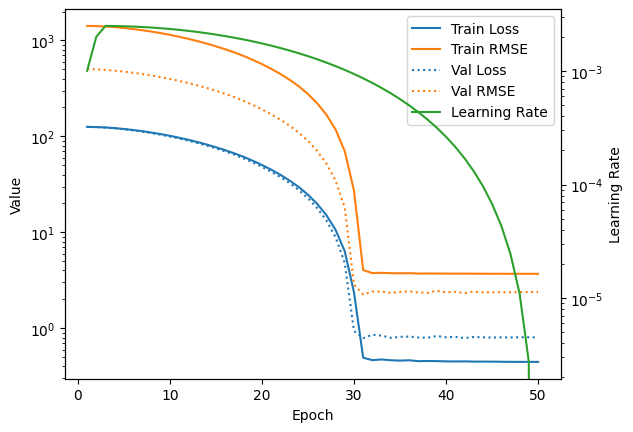

In [630]:
n = np.arange(1, EPOCHS+1)
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()